In [59]:
import os
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
from sklearn.model_selection import train_test_split
import random

In [60]:
def visualize_12_bands(img_path):
    band_names = [
        "Coastal Aerosol", "Blue", "Green", "Red",
        "NIR", "SWIR 1", "SWIR 2", "QA Band",
        "Merit DEM", "Copernicus DEM", "ESA World Cover", "Water Occur. Probability"
    ]
    
    # Load multi-channel tiff
    image = tifffile.imread(img_path).astype(np.float32)
    # print(image.shape)    

    # if image.shape[0] == 12:
    #     image = np.transpose(image, (1, 2, 0))
        
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    for i in range(12):
        ax = axes.flat[i]
        band_data = image[:, :, i]
        
        # Min-max scaling for visualization purposes
        b_min, b_max = band_data.min(), band_data.max()
        scaled = (band_data - b_min) / (b_max - b_min + 1e-8)
        print(band_names[i], "Range: ", b_min, ", ",b_max)
        im = ax.imshow(scaled)
        ax.set_title(band_names[i], fontsize=10)
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # print(image.shape)
    plt.tight_layout()
    plt.show()

Coastal Aerosol Range:  -165.0 ,  762.0
Blue Range:  -167.0 ,  1215.0
Green Range:  173.0 ,  1549.0
Red Range:  52.0 ,  1493.0
NIR Range:  422.0 ,  4360.0
SWIR 1 Range:  133.0 ,  3311.0
SWIR 2 Range:  67.0 ,  1847.0
QA Band Range:  64.0 ,  198.0
Merit DEM Range:  123.0 ,  160.0
Copernicus DEM Range:  145.0 ,  198.0
ESA World Cover Range:  10.0 ,  90.0
Water Occur. Probability Range:  0.0 ,  83.0


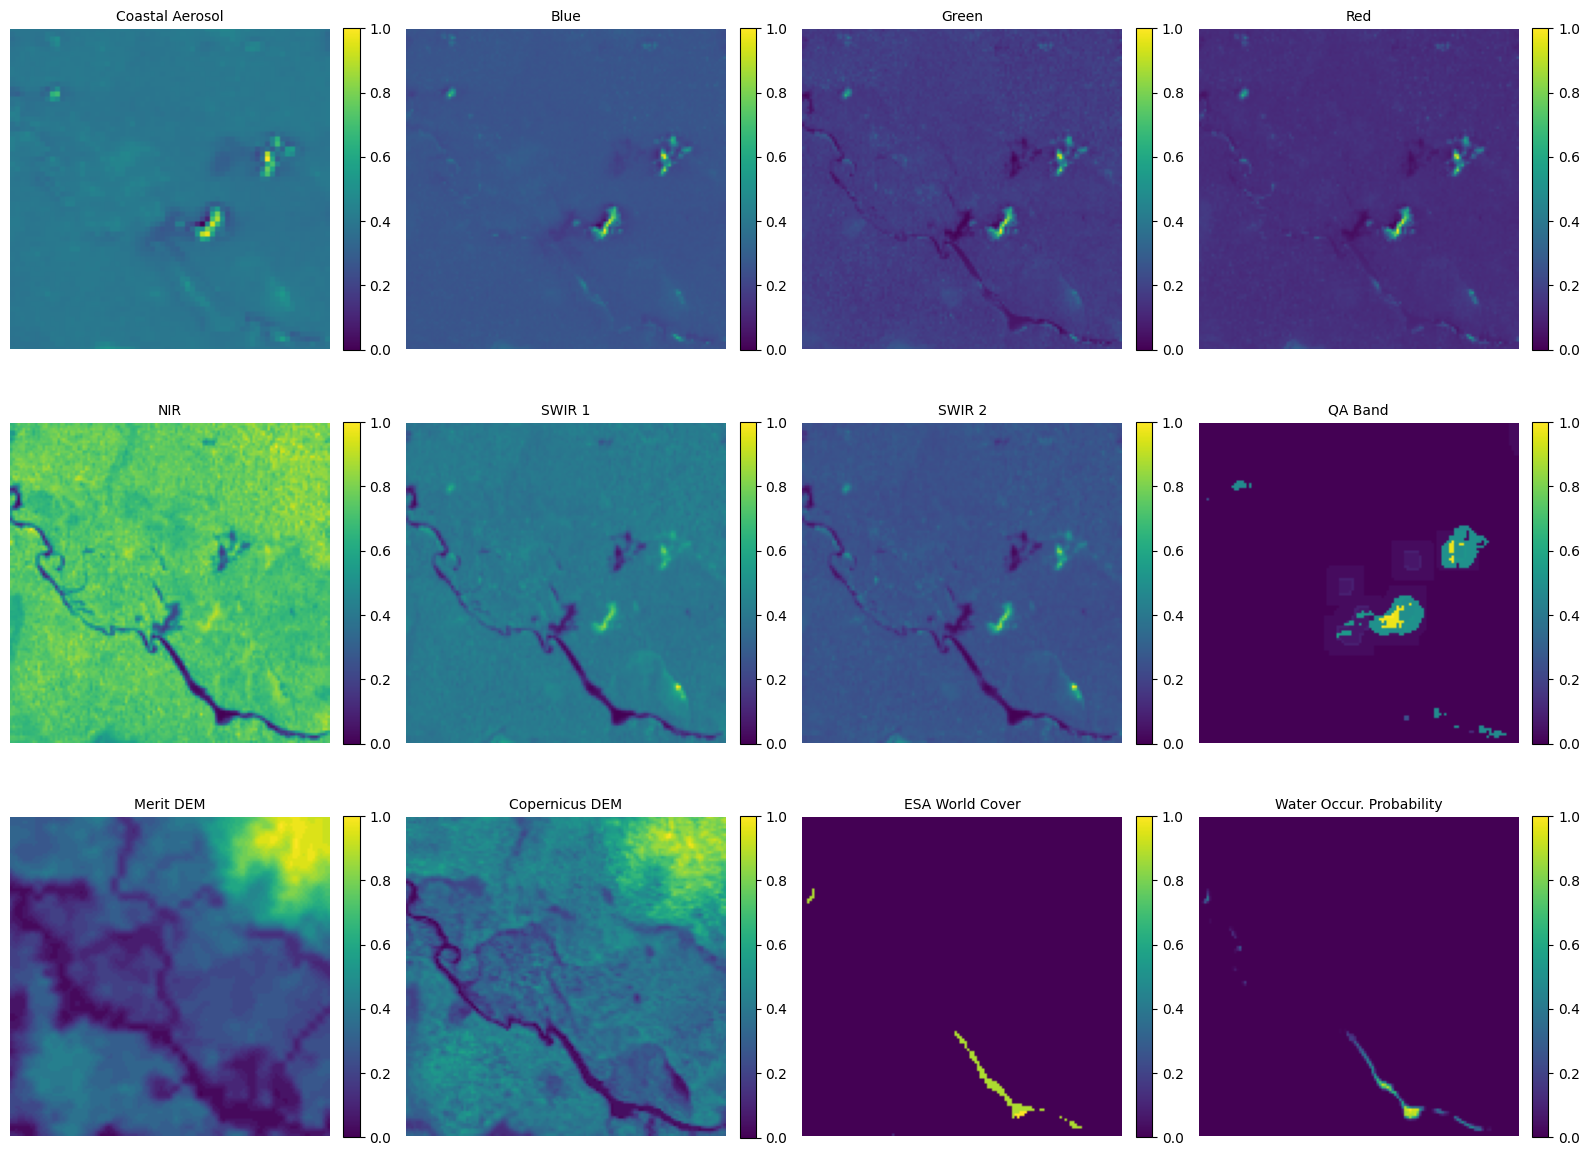

In [61]:
visualize_12_bands("/kaggle/input/datasets/omarabdelazez2004/water-data/data/images/105.tif")

In [62]:
def analyze_class_distribution(masks_dir, filenames):
    total_pixels = 0
    water_pixels = 0
    
    for fname in filenames:
        base_name = os.path.splitext(fname)[0]
        mask_path = os.path.join(masks_dir, f"{base_name}.png")
        
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            binary_mask = (mask > 0).astype(np.uint8)
            total_pixels += binary_mask.size
            water_pixels += np.sum(binary_mask)
            
    land_pixels = total_pixels - water_pixels
    print(f"Total Pixels: {total_pixels:,}")
    print(f"Land (Background) Pixels: {land_pixels:,} ({land_pixels/total_pixels*100:.2f}%)")
    print(f"Water (Positive) Pixels: {water_pixels:,} ({water_pixels/total_pixels*100:.2f}%)")
    print(f"Imbalance Ratio (Land:Water): {land_pixels / (water_pixels + 1e-8):.2f} : 1")

In [63]:
analyze_class_distribution("/kaggle/input/datasets/omarabdelazez2004/water-data/data/labels", ["142.tif"])

Total Pixels: 16,384
Land (Background) Pixels: 11,802 (72.03%)
Water (Positive) Pixels: 4,582 (27.97%)
Imbalance Ratio (Land:Water): 2.58 : 1


In [64]:
class WaterDataset(data.Dataset):
    ''' Custom loading for 12-bands dataset'''
    def __init__(self, images_dir, labels_dir, filenames, augmentations=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.filenames = filenames
        self.augmentations = augmentations

    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        fname = self.filenames[idx]
        # Load image
        img_path = os.path.join(self.images_dir, fname)
        image = tifffile.imread(img_path).astype(np.float32)

        if image.shape[0] == 12:
            pass
        elif image.shape[2] == 12:
            image = np.transpose(image,(2,0,1))
        else:
            raise ValueError(f"Unexpected image shape: {image.shape}")
        
        normalized_image = np.zeros_like(image)

        for c in range(11):
            band = image[c, :, :]
            b_min, b_max = band.min(), band.max()

            denom = b_max - b_min

            if denom == 0:
                denom = 1e-8  # Avoid division by zero

            normalized_image[c, :, :] = image[c, :, :] / denom
        normalized_image[11, :, :] = image[11, :, :]  / 100.0  # Normalize water occurrence probability to [0, 1]
        
        # Load Mask

        base_name = os.path.splitext(fname)[0]
        mask_path = os.path.join(self.labels_dir, f"{base_name}.png")

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found for {fname} at {mask_path}")
        
        binary_mask = (mask > 0).astype(np.float32)

        binary_mask = np.expand_dims(binary_mask, axis=0) # Expand dimenstions to (1, 128, 128) for pytorch

        image_tensor = torch.from_numpy(normalized_image)
        mask_tensor = torch.from_numpy(binary_mask)

        if self.augmentations:
            # apply augmentations (flips/ rotations) to image and mask
            #### Needs to be implemented
            image_tensor, mask_tensor = self.augmentations(image_tensor, mask_tensor)

        return image_tensor, mask_tensor
    
def get_water_dataloader(images_dir, masks_dir, filenames, batch_size=16, shuffle=True, num_workers=4):
    """
    Helper function to initialize and return a PyTorch DataLoader.
    """
    dataset = WaterDataset(
        images_dir=images_dir, 
        labels_dir=masks_dir, 
        filenames=filenames
    )
    
    dataloader = data.DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=shuffle, 
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    return dataloader

In [65]:
# class DoubleConv(nn.Module):
#     """(Conv2D ===> Batch Normalization ===> ReLU) * 2"""
#     def __init__(self, in_channels, out_channels, num_groups=8):
#         super(DoubleConv, self).__init__()
#         self.double_conv = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True)
#         )

#     def forward(self, x):
#         return self.double_conv(x)

# class UNet(nn.Module):
#     def __init__(self, in_channels=12, out_channels=1):
#         super(UNet, self).__init__()
        
#         # Downsampling Layers
#         self.inc = DoubleConv(in_channels, 64)
#         self.down1 = nn.Sequential(nn.MaxPool2d(kernel_size = 2, stride = 2), DoubleConv(64, 128))
#         self.down2 = nn.Sequential(nn.MaxPool2d(kernel_size = 2, stride = 2), DoubleConv(128, 256))
#         self.down3 = nn.Sequential(nn.MaxPool2d(kernel_size = 2, stride = 2), DoubleConv(256, 512))

#         # Upsampling Layers        
#         self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
#         self.conv1 = DoubleConv(512, 256) 
        
#         self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
#         self.conv2 = DoubleConv(256, 128) 
        
#         self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2 )
#         self.conv3 = DoubleConv(128, 64)   
        
#         self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

#     def forward(self, x):
#         # Forward pass through the encoder
#         x1 = self.inc(x)         
#         x2 = self.down1(x1)      
#         x3 = self.down2(x2)      
#         x4 = self.down3(x3)      
        
#         # Upsample with skip connections
#         up_1 = self.up1(x4)      
#         cat_1 = torch.cat([up_1, x3], dim=1)
#         c_1 = self.conv1(cat_1)          
#         up_2 = self.up2(c_1)     
#         cat_2 = torch.cat([up_2, x2], dim=1)
#         c_2 = self.conv2(cat_2)  
        
#         up_3 = self.up3(c_2)     
#         cat_3 = torch.cat([up_3, x1], dim=1) 
#         c_3 = self.conv3(cat_3)

#         logits = self.outc(c_3)
#         return logits

In [66]:
# class DoubleConv(nn.Module):
#     """(Conv2D ===> Batch Normalization ===> ReLU) * 2"""
#     def __init__(self, in_channels, out_channels, num_groups=8):
#         super(DoubleConv, self).__init__()
#         self.double_conv = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
#             nn.GroupNorm(num_groups, out_channels),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
#             nn.GroupNorm(num_groups, out_channels),
#             nn.ReLU(inplace=True)
#         )

#     def forward(self, x):
#         return self.double_conv(x)

# class UNet(nn.Module):
#     def __init__(self, in_channels=12, out_channels=1):
#         super(UNet, self).__init__()
        
#         # Downsampling Layers
#         self.inc = DoubleConv(in_channels, 64)
#         self.down1 = nn.Sequential(nn.MaxPool2d(kernel_size = 2, stride = 2), DoubleConv(64, 128))
#         self.down2 = nn.Sequential(nn.MaxPool2d(kernel_size = 2, stride = 2), DoubleConv(128, 256))
#         self.down3 = nn.Sequential(nn.MaxPool2d(kernel_size = 2, stride = 2), DoubleConv(256, 512))

#         # Upsampling Layers        
#         self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
#         self.conv1 = DoubleConv(512, 256) 
        
#         self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
#         self.conv2 = DoubleConv(256, 128) 
        
#         self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2 )
#         self.conv3 = DoubleConv(128, 64)   
        
#         self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

#     def forward(self, x):
#         # Forward pass through the encoder
#         x1 = self.inc(x)         
#         x2 = self.down1(x1)      
#         x3 = self.down2(x2)      
#         x4 = self.down3(x3)      
        
#         # Upsample with skip connections
#         up_1 = self.up1(x4)      
#         cat_1 = torch.cat([up_1, x3], dim=1)
#         c_1 = self.conv1(cat_1)          
#         up_2 = self.up2(c_1)     
#         cat_2 = torch.cat([up_2, x2], dim=1)
#         c_2 = self.conv2(cat_2)  
        
#         up_3 = self.up3(c_2)     
#         cat_3 = torch.cat([up_3, x1], dim=1) 
#         c_3 = self.conv3(cat_3)

#         logits = self.outc(c_3)
#         return logits

In [67]:
class DoubleConv(nn.Module):
    """(Conv2D ===> Batch Normalization ===> ReLU) * 2"""
    def __init__(self, in_channels, out_channels, group_names = 8):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(group_names, out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(group_names, out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1):
        super(UNet, self).__init__()
        
        # Downsampling Layers
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(kernel_size = 2, stride = 2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(kernel_size = 2, stride = 2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(kernel_size = 2, stride = 2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(kernel_size = 2, stride = 2), DoubleConv(512, 1024))

        # Upsampling Layers        
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(512, 256) 
        
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128) 
        
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2 )
        self.conv4 = DoubleConv(128, 64)   
        
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Forward pass through the encoder
        x1 = self.inc(x)         
        x2 = self.down1(x1)      
        x3 = self.down2(x2)      
        x4 = self.down3(x3)      
        x5 = self.down4(x4)      
        
        # Upsample with skip connections
        up_1 = self.up1(x5)      
        cat_1 = torch.cat([up_1, x4], dim=1)
        c_1 = self.conv1(cat_1)          
        up_2 = self.up2(c_1)     
        cat_2 = torch.cat([up_2, x3], dim=1)
        c_2 = self.conv2(cat_2)  
        
        up_3 = self.up3(c_2)     
        cat_3 = torch.cat([up_3, x2], dim=1) 
        c_3 = self.conv3(cat_3)

        up_4 = self.up4(c_3)
        cat_4 = torch.cat([up_4, x1], dim=1)
        c_4 = self.conv4(cat_4)

        logits = self.outc(c_4)
        return logits

In [68]:
class BCEDiceLoss(nn.Module):
    """
    A combined loss function that uses both Binary Cross-Entropy (BCE) 
    and Dice Loss to combat extreme class imbalance.
    """
    def __init__(self, bce_weight=1.0, dice_weight=1.0):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (probs_flat * targets_flat).sum()
        denominator = probs_flat.sum() + targets_flat.sum()
        
        dice_loss = 1.0 - (2.0 * intersection + 1e-8) / (denominator + 1e-8)
        
        return (self.bce_weight * bce_loss) + (self.dice_weight * dice_loss)

In [69]:
class MetricTracker:
    """
    Accumulates classification counts (TP, FP, FN, TN) and loss 
    across all batches within a single training or validation epoch.
    """
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.tp = 0.0
        self.fp = 0.0
        self.fn = 0.0
        self.tn = 0.0
        self.total_loss = 0.0
        self.total_samples = 0

    def update(self, logits, targets, loss_value):
        """
        Updates counts using the output logits and true target masks.
        """
        with torch.no_grad():
            preds = (logits > 0.0).float()
            
            # Flatten to simplify element-wise multiplication
            preds_flat = preds.view(-1)
            targets_flat = targets.view(-1)
            
            # Calculate classification outcomes
            self.tp += torch.sum(preds_flat * targets_flat).item()
            self.fp += torch.sum(preds_flat * (1.0 - targets_flat)).item()
            self.fn += torch.sum((1.0 - preds_flat) * targets_flat).item()
            self.tn += torch.sum((1.0 - preds_flat) * (1.0 - targets_flat)).item()
            
            # Accumulate loss weighted by batch size
            batch_size = logits.size(0)
            self.total_loss += loss_value * batch_size
            self.total_samples += batch_size

    def compute_metrics(self):
        """
        Computes the final aggregated metrics for the epoch.
        """
        eps = 1e-6
        precision = self.tp / (self.tp + self.fp + eps)
        recall = self.tp / (self.tp + self.fn + eps)
        f1_score = (2.0 * self.tp) / (2.0 * self.tp + self.fp + self.fn + eps)
        iou = self.tp / (self.tp + self.fp + self.fn + eps)
        avg_loss = self.total_loss / (self.total_samples)
        return {
            "loss": avg_loss,
            "precision": precision,
            "recall": recall,
            "f1_score": f1_score,
            "iou": iou
        }


history = {
    "train_loss": [],
    "train_precision": [],
    "train_recall": [],
    "train_f1": [],
    "train_iou": [],
    
    "val_loss": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_iou": []
}

def log_epoch_metrics(history_dict, train_metrics, val_metrics):
    """
    Appends the epoch metrics to the tracking lists.
    """
    # Training Metrics
    history_dict["train_loss"].append(train_metrics["loss"])
    history_dict["train_precision"].append(train_metrics["precision"])
    history_dict["train_recall"].append(train_metrics["recall"])
    history_dict["train_f1"].append(train_metrics["f1_score"])
    history_dict["train_iou"].append(train_metrics["iou"])
    
    # Validation Metrics
    history_dict["val_loss"].append(val_metrics["loss"])
    history_dict["val_precision"].append(val_metrics["precision"])
    history_dict["val_recall"].append(val_metrics["recall"])
    history_dict["val_f1"].append(val_metrics["f1_score"])
    history_dict["val_iou"].append(val_metrics["iou"])

In [70]:
def train_model(model, train_loader, val_loader, all_filenames,criterion, optimizer, num_epochs, device, save_path="best_unet_model.pth"):

    model.to(device)
    best_val_iou = -1.0
    
    history = {
        "train_loss": [], "train_acc": [], "train_precision": [], "train_recall": [], "train_f1": [], "train_iou": [],
        "val_loss": [], "val_acc": [], "val_precision": [], "val_recall": [], "val_f1": [], "val_iou": []
    }
    
    print(f"Starting training on device: {device}\n" + "-"*50)
    
    split_idx = int(len(all_filenames) * 0.8)

    for epoch in range(num_epochs):
        shuffled_filenames = all_filenames.copy()
        random.shuffle(shuffled_filenames)

        epoch_train_files = shuffled_filenames[:split_idx]
        epoch_val_files = shuffled_filenames[split_idx:]

        train_loader.dataset.filenames = epoch_train_files
        val_loader.dataset.filenames = epoch_val_files

        # Initialize trackers
        train_tracker = MetricTracker()
        val_tracker = MetricTracker()
        
        # Training Step
        model.train()
        for images, targets in train_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            
            # Update calculations
            train_tracker.update(logits, targets, loss.item())
            
        # Validation Step
        model.eval()
        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)
                
                logits = model(images)
                loss = criterion(logits, targets)
                
                # Update validation calculations
                val_tracker.update(logits, targets, loss.item())
                
        # Log Epoch Results
        train_results = train_tracker.compute_metrics()
        val_results = val_tracker.compute_metrics()
        
        # Save values
        history["train_loss"].append(train_results["loss"])
        history["train_precision"].append(train_results["precision"])
        history["train_recall"].append(train_results["recall"])
        history["train_f1"].append(train_results["f1_score"])
        history["train_iou"].append(train_results["iou"])
        
        history["val_loss"].append(val_results["loss"])
        history["val_precision"].append(val_results["precision"])
        history["val_recall"].append(val_results["recall"])
        history["val_f1"].append(val_results["f1_score"])
        history["val_iou"].append(val_results["iou"])
        
        # Checkpoint Save
        epoch_val_iou = val_results["iou"]
        is_best = epoch_val_iou > best_val_iou
        if is_best:
            best_val_iou = epoch_val_iou
            torch.save(model.state_dict(), save_path)
            save_msg = f" -> Saved new best model (Val IoU: {best_val_iou:.4f})"
        else:
            save_msg = ""
            
        # Print epoch metrics
        print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | "
              f"Train Loss: {train_results['loss']:.4f} | Train IoU: {train_results['iou']:.4f} || "
              f"Val Loss: {val_results['loss']:.4f} | Val IoU: {val_results['iou']:.4f}{save_msg}")
        
    print("-"*50 + f"\nTraining Complete. Best Validation IoU achieved: {best_val_iou:.4f}")
    return history

In [71]:
def run_pipeline(images_dir, masks_dir, num_epochs=30, batch_size=16, lr=1e-4):
    """
    Prepares splits, initializes the dataloaders with dynamic train-split, compiles the model,
    and runs the training process.
    """
    filenames = [f for f in os.listdir(images_dir) if f.endswith('.tif')]
    if len(filenames) == 0:
         raise FileNotFoundError(f"No .tif files found in the directory: {images_dir}")

    dummy_train, dummy_val = train_test_split(filenames, test_size=0.2, random_state=42)
    print(f"Dataset summary: {len(filenames)} total samples | {len(dummy_train)} Train | {len(dummy_val)} Val")

    
    train_loader = get_water_dataloader(
        images_dir=images_dir, 
        masks_dir=masks_dir, 
        filenames=dummy_train, 
        batch_size=batch_size, 
        shuffle=True
    )
    val_loader = get_water_dataloader(
        images_dir=images_dir, 
        masks_dir=masks_dir, 
        filenames=dummy_val, 
        batch_size=batch_size, 
        shuffle=False
    )
    
    # Initialize Model
    model = UNet(in_channels=12, out_channels=1)
    
    # Binary Cross-Entropy + Dice Loss
    criterion = BCEDiceLoss(bce_weight=0.8, dice_weight=0.2)
    
    # Optimize
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    history = train_model(
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader,
        all_filenames=filenames,
        criterion=criterion, 
        optimizer=optimizer, 
        num_epochs=num_epochs, 
        device=device,
        save_path="best_unet_water_model.pth"
    )
    
    return history

In [72]:
images_folder = "/kaggle/input/datasets/omarabdelazez2004/water-data/data/images"
labels_folder = "/kaggle/input/datasets/omarabdelazez2004/water-data/data/labels"

run_history = run_pipeline(
    images_dir=images_folder, 
    masks_dir=labels_folder, 
    num_epochs=150, 
    batch_size=16, 
    lr=1e-5
)

Dataset summary: 306 total samples | 244 Train | 62 Val
Starting training on device: cuda
--------------------------------------------------
Epoch 01/150 | Train Loss: 0.5332 | Train IoU: 0.1706 || Val Loss: 0.4391 | Val IoU: 0.4209 -> Saved new best model (Val IoU: 0.4209)
Epoch 02/150 | Train Loss: 0.3975 | Train IoU: 0.5128 || Val Loss: 0.3709 | Val IoU: 0.5736 -> Saved new best model (Val IoU: 0.5736)
Epoch 03/150 | Train Loss: 0.3445 | Train IoU: 0.5713 || Val Loss: 0.4111 | Val IoU: 0.4016
Epoch 04/150 | Train Loss: 0.3498 | Train IoU: 0.5327 || Val Loss: 0.3882 | Val IoU: 0.5179
Epoch 05/150 | Train Loss: 0.3171 | Train IoU: 0.6126 || Val Loss: 0.2939 | Val IoU: 0.5238
Epoch 06/150 | Train Loss: 0.3023 | Train IoU: 0.6042 || Val Loss: 0.3189 | Val IoU: 0.5817 -> Saved new best model (Val IoU: 0.5817)
Epoch 07/150 | Train Loss: 0.2802 | Train IoU: 0.6560 || Val Loss: 0.3043 | Val IoU: 0.5943 -> Saved new best model (Val IoU: 0.5943)
Epoch 08/150 | Train Loss: 0.2651 | Train IoU: 

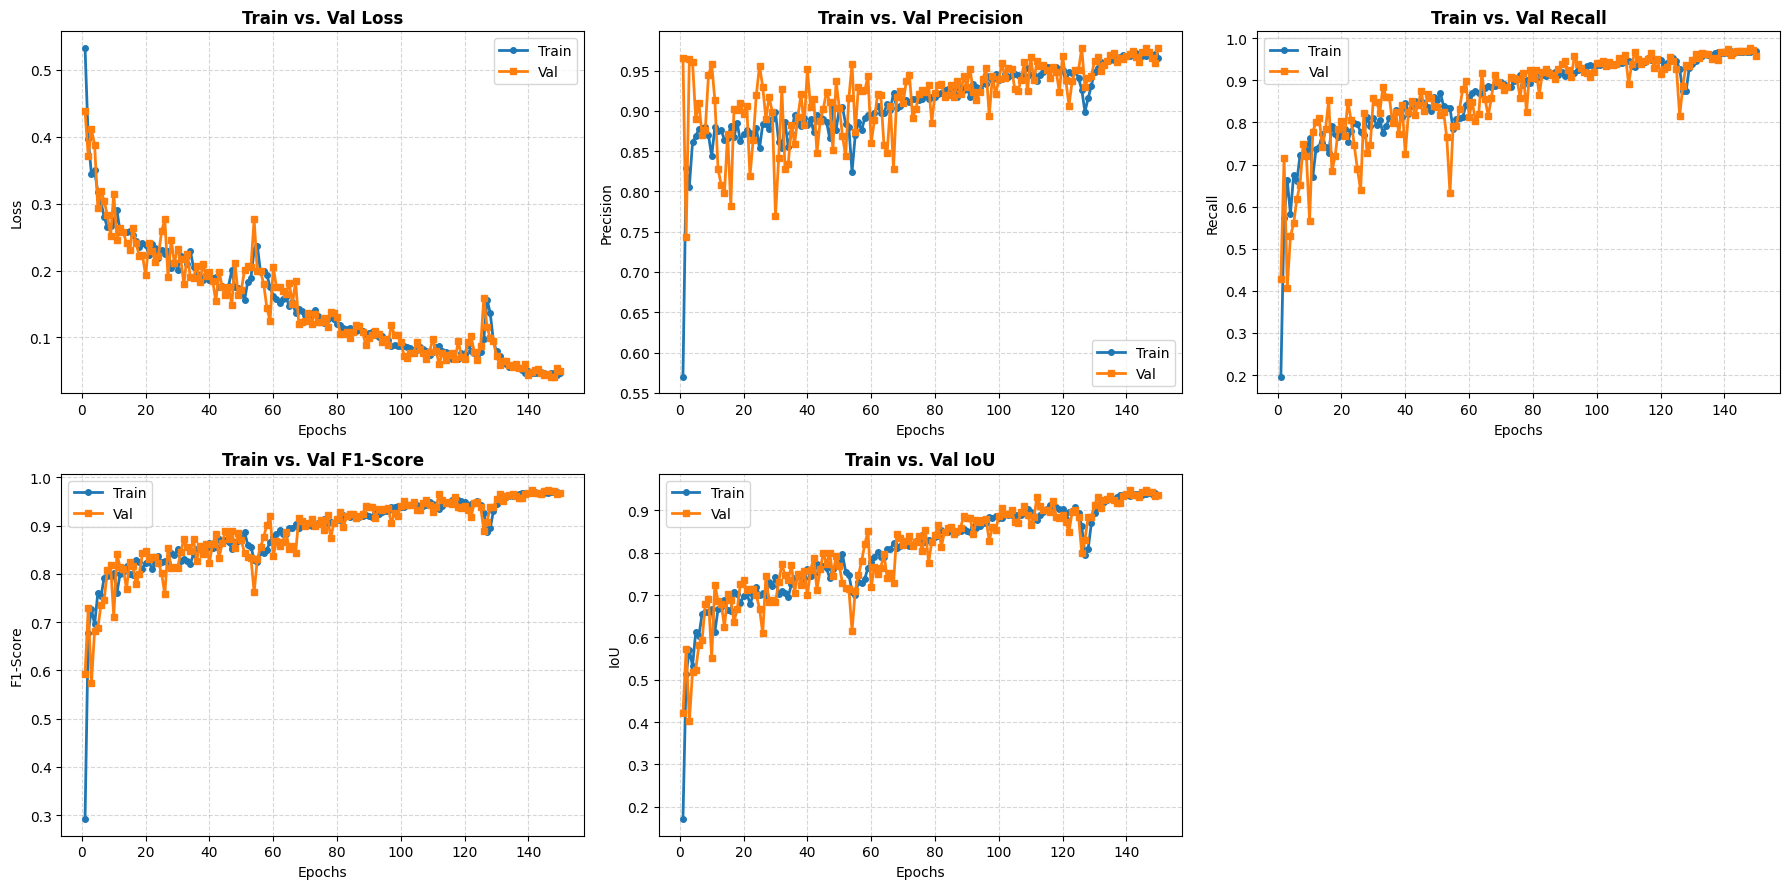

In [73]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Plots training and validation metrics against each other over the training epochs.
    """
    # Determine the number of epochs based on logged history
    epochs = range(1, len(history["train_loss"]) + 1)
    
    # Define pairs of metrics to compare
    metric_pairs = [
        ("Loss", "train_loss", "val_loss"),
        ("Precision", "train_precision", "val_precision"),
        ("Recall", "train_recall", "val_recall"),
        ("F1-Score", "train_f1", "val_f1"),
        ("IoU", "train_iou", "val_iou")
    ]
    
    # Add Accuracy to the plot if it was tracked during training
    if "train_acc" in history and len(history["train_acc"]) > 0:
        metric_pairs.append(("Accuracy", "train_acc", "val_acc"))
        
    num_plots = len(metric_pairs)
    
    # Configure grid layout (e.g., 2 rows, 3 columns for 6 metrics)
    cols = 3
    rows = (num_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4.5 * rows))
    axes = axes.flatten()
    
    for idx, (metric_name, train_key, val_key) in enumerate(metric_pairs):
        ax = axes[idx]
        
        # Verify the key exists and contains data before plotting
        if train_key in history and val_key in history:
            ax.plot(epochs, history[train_key], label='Train', color='#1f77b4', linewidth=2, marker='o', markersize=4)
            ax.plot(epochs, history[val_key], label='Val', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
            
            ax.set_title(f"Train vs. Val {metric_name}", fontsize=12, fontweight='bold')
            ax.set_xlabel("Epochs", fontsize=10)
            ax.set_ylabel(metric_name, fontsize=10)
            ax.legend(loc='best')
            ax.grid(True, linestyle='--', alpha=0.5)
            
    # Remove any extra empty subplots from the grid
    for idx in range(num_plots, len(axes)):
        fig.delaxes(axes[idx])
        
    plt.tight_layout()
    plt.show()

plot_training_history(run_history)